# 1.Compound poisson process

## 1.1 Through uniform distribution

In [ ]:
import numpy as np
import sympy as smp
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation,PillowWriter
from moviepy.editor import VideoFileClip
import os
from google.colab import files
import shutil

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



In [ ]:
# Parameters
T = 1.0                 # final time
n = 1000                # number of discretization points
t = np.linspace(0, T, n)

b = 0.2                 # drift
sigma = 0.5             # Brownian volatility

lambda_ = 5             # Poisson intensity
beta = 0.3              # Laplace jump size scale   (Y ~ Laplace(0, beta))


In [ ]:
dt = t[1] - t[0]
W = np.cumsum(np.sqrt(dt) * np.random.normal(size=n))


In [ ]:
# Number of jumps
N_T = np.random.poisson(lambda_ * T)

# Jump times (ordered)
U = np.sort(np.random.uniform(0, T, N_T))

# Jump sizes (Laplace)
Y = np.random.laplace(loc=0, scale=beta, size=N_T)


In [1]:
# creation of the levy process

X = b * t + sigma * W               #  we builf the continuous part :drift + Brownian part
jump_process = np.zeros_like(t)

current_jump_sum = 0
j = 0

# we generate the jump that we will add later
for i in range(n):
    while j < N_T and U[j] <= t[i]:
        current_jump_sum += Y[j]
        j += 1
    jump_process[i] = current_jump_sum

# Final Lévy process
X = X + jump_process


NameError: name 'b' is not defined

In [ ]:
X_disc = X.copy()  # copy full path

# Find indices in t_grid closest to jump times
jump_indices = np.searchsorted(t, U)

# Remove the continuous value **just before the jump to make the gap visible on the plot
for idx in jump_indices:
    if idx < len(X_disc):
        X_disc[idx] = np.nan


Text(0, 0.5, 'X(t)')

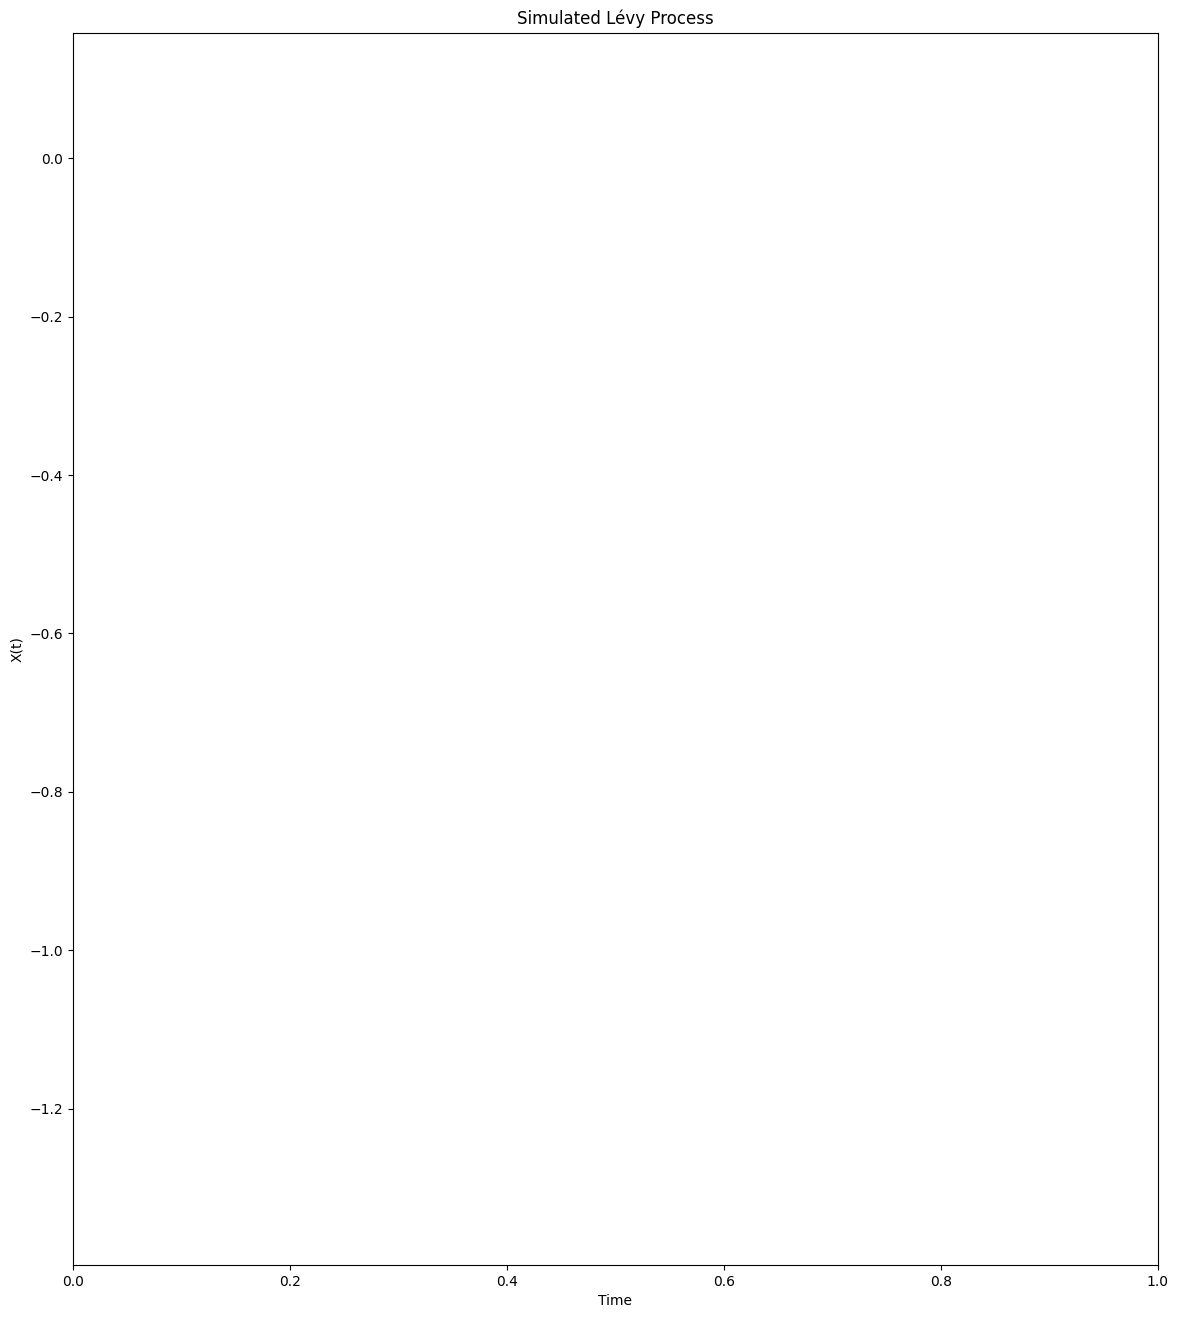

In [ ]:
fig, ax = plt.subplots(figsize=(14,16))
line, = ax.plot([], [], lw=2, color="blue")
jump_points = ax.scatter([], [], color="red", s=30)

ax.set_xlim(0, T)
ax.set_ylim(np.min(X)*1.1, np.max(X)*1.1)
ax.set_title("Simulated Lévy Process")
ax.set_xlabel("Time")
ax.set_ylabel("X(t)")


In [ ]:
X_jump = np.array([
    b*u + sigma*np.interp(u, t, W) + np.sum(Y[:i+1])
    for i, u in enumerate(U)
])


In [ ]:
def update(frame):
    line.set_data(t[:frame], X_disc[:frame])

    # gradually reveal jumps
    visible = frame // 5  # one jump every 5 frames
    visible = min(visible, N_T)

    if visible > 0:
        jump_points.set_offsets(np.column_stack((U[:visible], X_jump[:visible])))
    else:
        jump_points.set_offsets(np.empty((0,2)))

    return line, jump_points


In [ ]:
ani = FuncAnimation(fig, update, frames=n, interval=20, blit=True)
ani.save("levy_brownian2.gif", writer=PillowWriter(fps=30))
plt.close(fig)


## 1.1 throught exponential waiting time

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# Simulation parameters
T = 1.0            # final time
n = 1000            # number of grid points
t_grid = np.linspace(0, T, n)

# Lévy process parameters
b = 0.2            # drift
sigma = 0.5        # Brownian volatility
lambda_ = 5        # Poisson intensity
beta = 0.3         # Laplace scale for jumps


In [ ]:
dt = t_grid[1] - t_grid[0]
W = np.cumsum(np.sqrt(dt) * np.random.normal(size=n))
F = b * t_grid + sigma * W    # continuous part


In [ ]:
# Generate exponential waiting times
waiting_times = np.random.exponential(scale=1/lambda_, size=1000)  # generate more than needed
jump_times = np.cumsum(waiting_times)
jump_times = jump_times[jump_times <= T]  # only keep jumps within [0, T]
N_T = len(jump_times)


In [ ]:
Y = np.random.laplace(loc=0, scale=beta, size=N_T)


In [ ]:
jump_process = np.zeros_like(t_grid)
current_jump_sum = 0
j = 0

for i, t in enumerate(t_grid):
    while j < N_T and jump_times[j] <= t:
        current_jump_sum += Y[j]
        j += 1
    jump_process[i] = current_jump_sum

# Full Lévy process
X_t = F + jump_process


In [ ]:
X_disc = X_t.copy()  # copy full path

# Find indices in t_grid closest to jump times
jump_indices = np.searchsorted(t_grid, jump_times)

# Remove the continuous value **just before the jump**
# Option 1: set it to NaN so the plot breaks
for idx in jump_indices:
    if idx < len(X_disc):
        X_disc[idx] = np.nan


In [ ]:
G = np.array([
    np.interp(u, t_grid, F) + np.sum(Y[:i+1])
    for i, u in enumerate(jump_times)
])


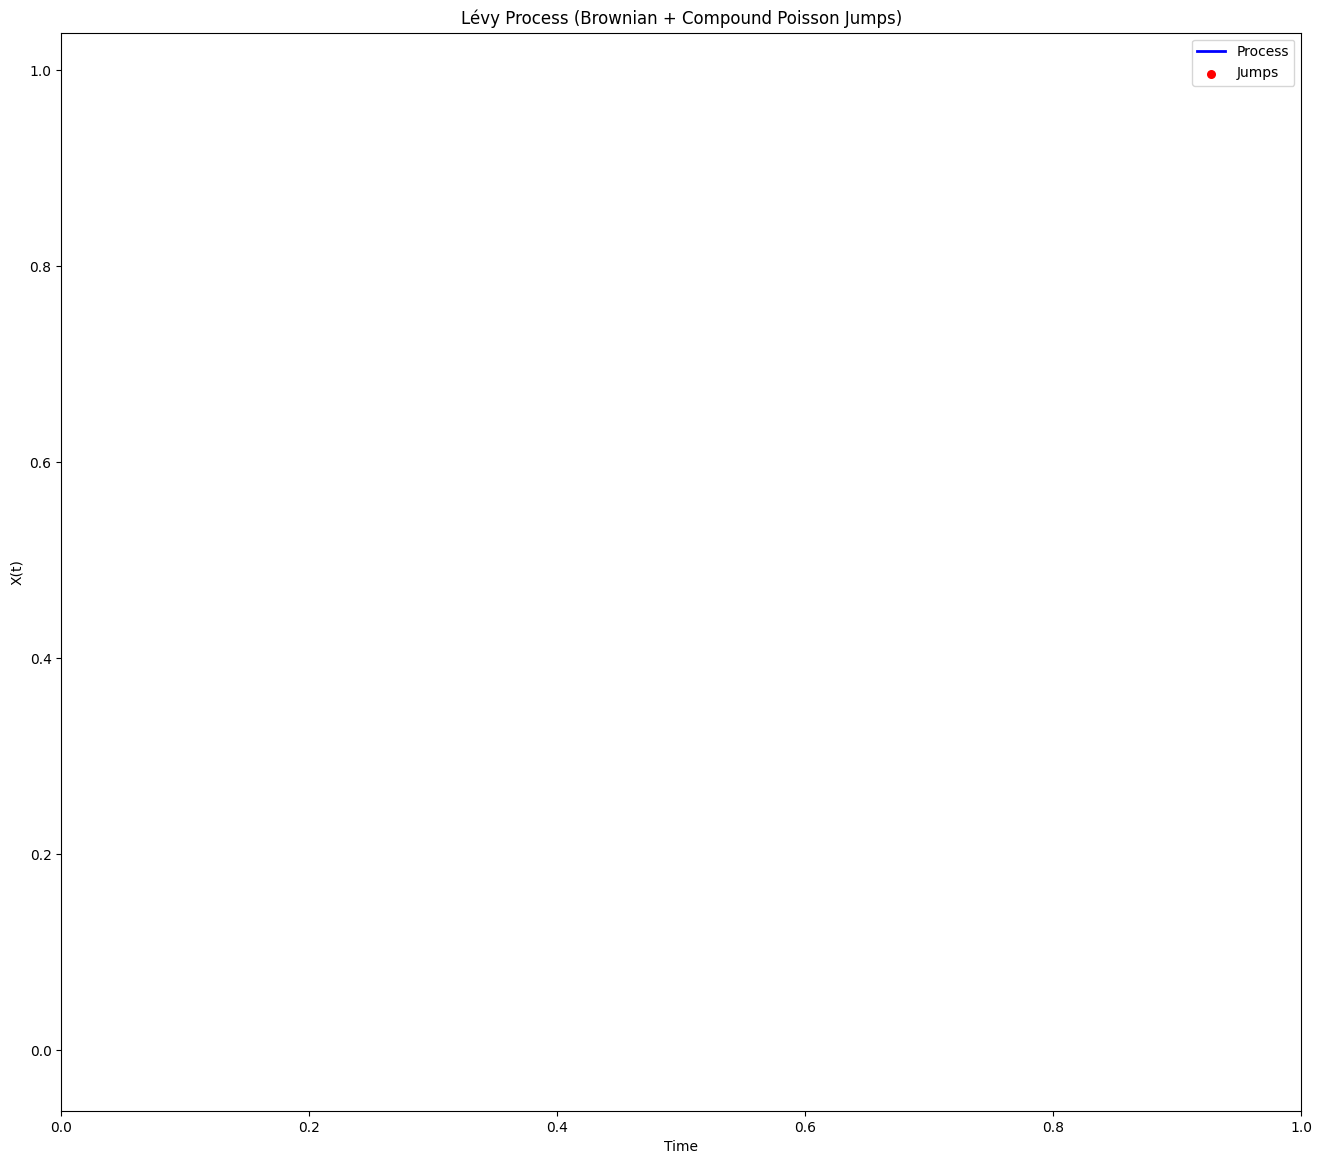

In [ ]:
fig, ax = plt.subplots(figsize=(16,14))
line, = ax.plot([], [], lw=2, color="blue")
points = ax.scatter([], [], color="red", s=30)

ax.set_xlim(0, T)
ax.set_ylim(np.min(X_t)*1.1, np.max(X_t)*1.1)
ax.set_xlabel("Time")
ax.set_ylabel("X(t)")
ax.set_title("Lévy Process (Brownian + Compound Poisson Jumps)")
ax.legend(["Process", "Jumps"])


In [ ]:
def update(frame):
    line.set_data(t_grid[:frame], X_disc[:frame])

    # Gradual display of jumps (1 jump every 5 frames)
    visible_jumps = frame // 5
    visible_jumps = min(visible_jumps, N_T)
    if visible_jumps > 0:
        points.set_offsets(np.column_stack((jump_times[:visible_jumps], G[:visible_jumps])))
    else:
        points.set_offsets(np.empty((0,2)))

    return line, points


In [ ]:
ani = FuncAnimation(fig, update, frames=n, interval=50, blit=True)
ani.save("levy_brownian_exponential.gif", writer=PillowWriter(fps=30))
plt.close(fig)


##  princing up-and-out call option

In [ ]:
# import numpy as np

# Option parameters
S0 = 100        # initial stock price
K = 50         # strike
H = 80         # barrier
T = 1.0         # maturity
r = 0.05        # risk-free rate
# b = 200         # barrier option

# Lévy process parameters
mu = 0.05
sigma = 0.2
lambda_ = 5
beta = 0.1      # jump size scale (Laplace)
n_paths = 500 # Monte Carlo paths



In [ ]:
payoffs = np.zeros((n_paths,))

for i in range(n_paths):
    # Jump process
    jump_times = np.cumsum(np.random.exponential(scale=1/lambda_, size=250))
    jump_times = jump_times[jump_times <= T]
    # print(len(jump_times))
    N_t = len(jump_times)

    if N_t>0:
      Y = np.cumsum(np.random.laplace(loc=0, scale=beta, size=N_t))

      # Brownian increments
      X = np.zeros(N_t)

      # W = np.random.normal(0, np.sqrt(jump_times[0]-jump_times[1]))
      X_T = mu*T + sigma*np.random.normal(0, np.sqrt(T)) + Y[-1]

      for k in range(N_t):
          W = np.random.normal(0, np.sqrt(jump_times[k]))
          X[k] = mu*jump_times[k] + sigma*W + Y[k]

      d_jump_times = np.zeros(N_t)
      d_jump_times[1:] = jump_times[:-1]

      dt = jump_times - d_jump_times
      b  = sigma**2 * dt


      d_X = np.zeros(N_t)
      d_X[1:] = X[:-1]

      c=1 - np.exp(-2*(X - H)*(d_X - H) / b)

      barrier_prob = np.prod((X < H) * c)

      payoffs[i]=np.maximum(S0*np.exp(X_T)-K,0)*barrier_prob


    else:

      X_T = mu*T + sigma*np.random.normal(0, np.sqrt(T))
      c=1 - np.exp(-2*(X_T - H)*(- H)/(T * sigma**2 ))
      payoffs[i]=np.maximum(S0*np.exp(X_T)-K,0)*(X_T<H)*c


In [ ]:
option_price = np.exp(-r*T) *np.mean(payoffs)
print("Up-and-out call option price:", option_price)

Up-and-out call option price: 58.238843135485936
